# 📊 Task 5: Interactive Business Dashboard in Streamlit

**Objective:** Build an interactive Streamlit dashboard for analyzing sales, profit, and segment-wise performance from the Global Superstore dataset.

**Author:** Muneeb Ur Rehman | BS Information Technology, University of Sargodha  
**Dataset:** Global Superstore (51,290 records across 13 regions, 3 categories)  
**Tool:** Streamlit + Plotly  

---

## 📋 Problem Statement

Business stakeholders need a self-service dashboard to answer:
- Which regions and categories drive the most revenue?
- How are sales trending over time?
- Who are our top customers?
- Does discount strategy actually hurt profit margins?

This notebook covers the **EDA and visual analysis** that underpins the Streamlit dashboard. The full interactive app is in `app.py`.


## 📦 1. Import Libraries

In [26]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

plt.rcParams.update({
    'figure.facecolor': '#0d1117', 'axes.facecolor': '#161b22',
    'axes.edgecolor': '#30363d',   'axes.labelcolor': '#e6edf3',
    'xtick.color': '#8b949e',      'ytick.color': '#8b949e',
    'text.color': '#e6edf3',       'grid.color': '#21262d',
    'grid.alpha': 0.5,             'font.family': 'DejaVu Sans',
})

C_BLUE   = '#58a6ff'; C_GREEN  = '#3fb950'; C_RED   = '#f85149'
C_ORANGE = '#d29922'; C_PURPLE = '#bc8cff'
PALETTE  = [C_BLUE, C_GREEN, C_RED, C_ORANGE, C_PURPLE]

print("✅ Libraries loaded")


✅ Libraries loaded


## 📂 2. Dataset Loading & Overview

**Source:** Global Superstore — a retail analytics dataset covering orders across regions, categories, and customer segments.


In [27]:
df = pd.read_csv('../data/Global_Superstore2.csv', parse_dates=['Order Date'], encoding='latin-1')
df['Year']    = df['Order Date'].dt.year
df['Month']   = df['Order Date'].dt.month
df['Quarter'] = df['Order Date'].dt.to_period('Q').astype(str)
df['Profit Margin %'] = (df['Profit'] / df['Sales'] * 100).round(2)

print(f"Shape: {df.shape}")
print(f"Date range: {df['Order Date'].min().date()} → {df['Order Date'].max().date()}")
print(f"\nColumn types:")
print(df.dtypes.to_string())
df.head()

Shape: (51290, 28)
Date range: 2011-01-01 → 2014-12-31

Column types:
Row ID                      int64
Order ID                   object
Order Date         datetime64[ns]
Ship Date                  object
Ship Mode                  object
Customer ID                object
Customer Name              object
Segment                    object
City                       object
State                      object
Country                    object
Postal Code               float64
Market                     object
Region                     object
Product ID                 object
Category                   object
Sub-Category               object
Product Name               object
Sales                     float64
Quantity                    int64
Discount                  float64
Profit                    float64
Shipping Cost             float64
Order Priority             object
Year                        int32
Month                       int32
Quarter                    object
Profit Margi

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,City,State,...,Sales,Quantity,Discount,Profit,Shipping Cost,Order Priority,Year,Month,Quarter,Profit Margin %
0,32298,CA-2012-124891,2012-07-31,31-07-2012,Same Day,RH-19495,Rick Hansen,Consumer,New York City,New York,...,2309.650,7,0.0,762.1845,933.57,Critical,2012,7,2012Q3,33.00
1,26341,IN-2013-77878,2013-02-05,07-02-2013,Second Class,JR-16210,Justin Ritter,Corporate,Wollongong,New South Wales,...,3709.395,9,0.1,-288.7650,923.63,Critical,2013,2,2013Q1,-7.78
2,25330,IN-2013-71249,2013-10-17,18-10-2013,First Class,CR-12730,Craig Reiter,Consumer,Brisbane,Queensland,...,5175.171,9,0.1,919.9710,915.49,Medium,2013,10,2013Q4,17.78
3,13524,ES-2013-1579342,2013-01-28,30-01-2013,First Class,KM-16375,Katherine Murray,Home Office,Berlin,Berlin,...,2892.510,5,0.1,-96.5400,910.16,Medium,2013,1,2013Q1,-3.34
4,47221,SG-2013-4320,2013-11-05,06-11-2013,Same Day,RH-9495,Rick Hansen,Consumer,Dakar,Dakar,...,2832.960,8,0.0,311.5200,903.04,Critical,2013,11,2013Q4,11.00


In [28]:
# Data quality check
print("Missing Values:")
print(df.isnull().sum())
print(f"\nDuplicate rows: {df.duplicated().sum()}")
print(f"\nBasic Stats:")
print(df[['Sales','Profit','Quantity','Discount']].describe().round(2).to_string())


Missing Values:
Row ID                 0
Order ID               0
Order Date             0
Ship Date              0
Ship Mode              0
Customer ID            0
Customer Name          0
Segment                0
City                   0
State                  0
Country                0
Postal Code        41296
Market                 0
Region                 0
Product ID             0
Category               0
Sub-Category           0
Product Name           0
Sales                  0
Quantity               0
Discount               0
Profit                 0
Shipping Cost          0
Order Priority         0
Year                   0
Month                  0
Quarter                0
Profit Margin %        0
dtype: int64

Duplicate rows: 0

Basic Stats:
          Sales    Profit  Quantity  Discount
count  51290.00  51290.00  51290.00  51290.00
mean     246.49     28.61      3.48      0.14
std      487.57    174.34      2.28      0.21
min        0.44  -6599.98      1.00      0.00
25%     

## 🔍 3. Exploratory Data Analysis

Regional Performance:
        Region        Sales       Profit  Orders
       Central 2.822303e+06 311403.98164    5249
         South 1.600907e+06 140355.76618    3270
         North 1.248166e+06 194597.95252    2356
       Oceania 1.100185e+06 120089.11200    1744
Southeast Asia 8.844232e+05  17852.32900    1517
    North Asia 8.483098e+05 165578.42100    1150
          EMEA 8.061613e+05  43897.97100    2462
        Africa 7.837732e+05  88871.63100    2232
  Central Asia 7.528266e+05 132480.18700    1026
          West 7.254578e+05 108418.44890    1611
          East 6.787812e+05  91522.78000    1401
     Caribbean 3.242809e+05  34571.32104     855
        Canada 6.692817e+04  17817.39000     201


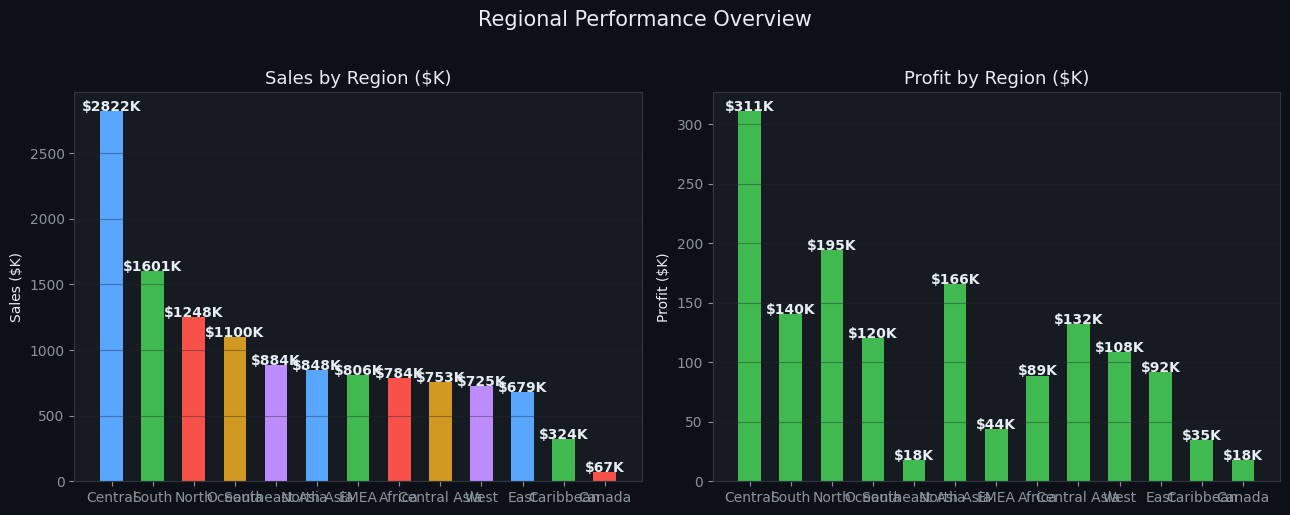

In [29]:
# 3.1 Sales & Profit by Region
region_df = df.groupby('Region').agg(
    Sales=('Sales','sum'),
    Profit=('Profit','sum'),
    Orders=('Order ID','nunique')
).reset_index().sort_values('Sales', ascending=False)

print("Regional Performance:")
print(region_df.to_string(index=False))

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
fig.patch.set_facecolor('#0d1117')

bars = axes[0].bar(region_df['Region'], region_df['Sales']/1000,
                   color=PALETTE[:len(region_df)], edgecolor='none', width=0.55)
for bar, val in zip(bars, region_df['Sales']):
    axes[0].text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.5,
                 f'${val/1000:.0f}K', ha='center', fontsize=10, fontweight='bold')
axes[0].set_title('Sales by Region ($K)', fontsize=13)
axes[0].set_ylabel('Sales ($K)'); axes[0].grid(axis='y', alpha=0.4)

bars2 = axes[1].bar(region_df['Region'], region_df['Profit']/1000,
                    color=[C_GREEN if p>0 else C_RED for p in region_df['Profit']],
                    edgecolor='none', width=0.55)
for bar, val in zip(bars2, region_df['Profit']):
    axes[1].text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.1,
                 f'${val/1000:.0f}K', ha='center', fontsize=10, fontweight='bold')
axes[1].set_title('Profit by Region ($K)', fontsize=13)
axes[1].set_ylabel('Profit ($K)'); axes[1].grid(axis='y', alpha=0.4)

plt.suptitle('Regional Performance Overview', fontsize=15, color='#e6edf3', y=1.02)
plt.tight_layout()
plt.savefig('../images/region_performance.png', dpi=150, bbox_inches='tight', facecolor='#0d1117')
plt.show()


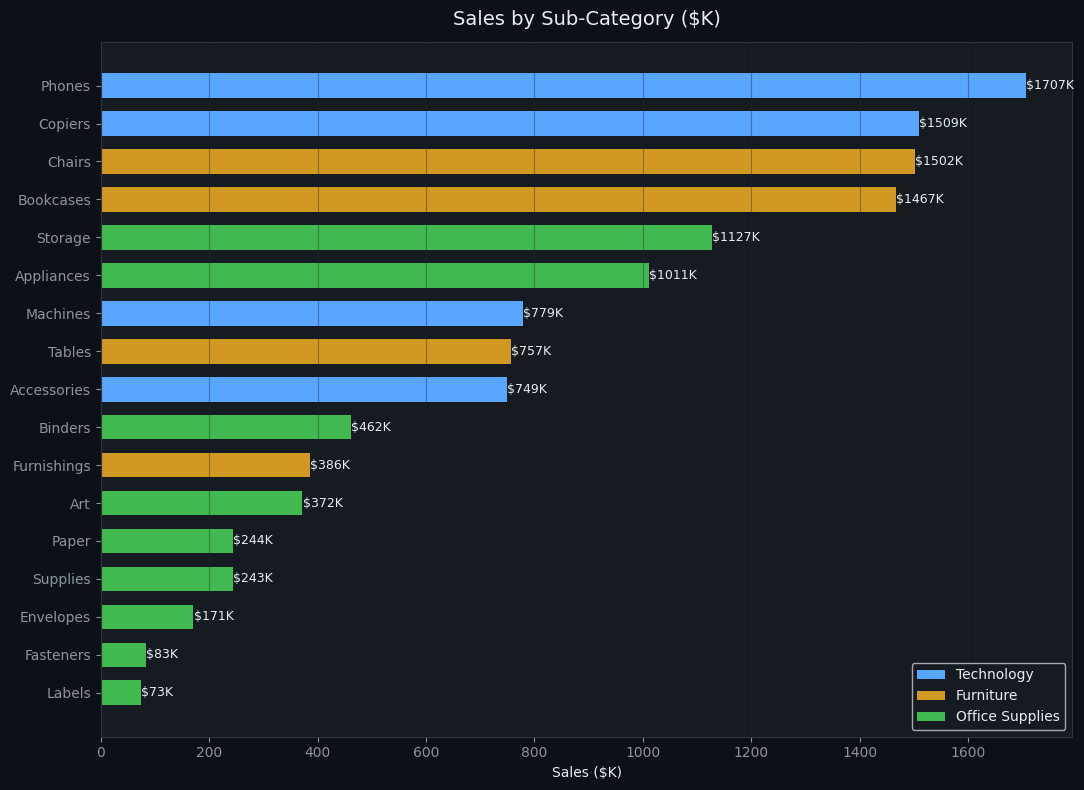

In [30]:
# 3.2 Category & Sub-Category Analysis
cat_df = df.groupby(['Category','Sub-Category']).agg(
    Sales=('Sales','sum'),
    Profit=('Profit','sum')
).reset_index().sort_values('Sales', ascending=True)

fig, ax = plt.subplots(figsize=(11, 8))
fig.patch.set_facecolor('#0d1117')

color_map = {'Technology': C_BLUE, 'Furniture': C_ORANGE, 'Office Supplies': C_GREEN}
bar_colors = [color_map[c] for c in cat_df['Category']]
bars = ax.barh(cat_df['Sub-Category'], cat_df['Sales']/1000, color=bar_colors,
               edgecolor='none', height=0.65)
for bar, val in zip(bars, cat_df['Sales']):
    ax.text(bar.get_width()+0.5, bar.get_y()+bar.get_height()/2,
            f'${val/1000:.0f}K', va='center', fontsize=9)

from matplotlib.patches import Patch
legend_handles = [Patch(facecolor=v, label=k) for k, v in color_map.items()]
ax.legend(handles=legend_handles, fontsize=10, loc='lower right')
ax.set_title('Sales by Sub-Category ($K)', fontsize=14, pad=12)
ax.set_xlabel('Sales ($K)'); ax.grid(axis='x', alpha=0.4)
plt.tight_layout()
plt.savefig('../images/category_breakdown.png', dpi=150, bbox_inches='tight', facecolor='#0d1117')
plt.show()


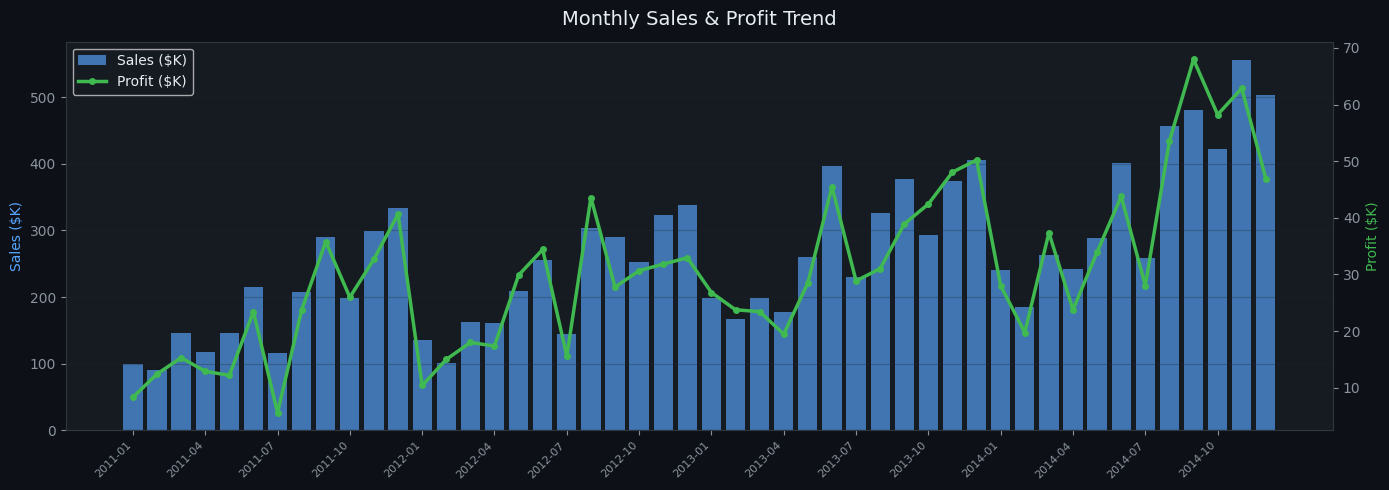

In [31]:
# 3.3 Monthly Sales Trend
monthly = (df.groupby(df['Order Date'].dt.to_period('M').astype(str))
             .agg(Sales=('Sales','sum'), Profit=('Profit','sum'))
             .reset_index().rename(columns={'Order Date':'Period'}))

fig, ax1 = plt.subplots(figsize=(14, 5))
fig.patch.set_facecolor('#0d1117')
ax2 = ax1.twinx()

ax1.bar(range(len(monthly)), monthly['Sales']/1000, color=C_BLUE, alpha=0.65,
        label='Sales ($K)', width=0.8)
ax2.plot(range(len(monthly)), monthly['Profit']/1000, color=C_GREEN,
         lw=2.5, marker='o', markersize=4, label='Profit ($K)')

ax1.set_xticks(range(0, len(monthly), 3))
ax1.set_xticklabels(monthly['Period'].iloc[::3], rotation=45, ha='right', fontsize=8)
ax1.set_ylabel('Sales ($K)', color=C_BLUE)
ax2.set_ylabel('Profit ($K)', color=C_GREEN)
ax1.set_title('Monthly Sales & Profit Trend', fontsize=14, pad=12)
ax1.grid(axis='y', alpha=0.3)

lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1+lines2, labels1+labels2, loc='upper left', fontsize=10)
plt.tight_layout()
plt.savefig('../images/monthly_trend.png', dpi=150, bbox_inches='tight', facecolor='#0d1117')
plt.show()


Segment KPIs:
    Segment        Sales       Profit  Orders  AvgOrderValue  Margin %
   Consumer 6.507949e+06 749239.78206   13104     245.416299      11.5
  Corporate 3.824698e+06 441208.32866    7673     247.890176      11.5
Home Office 2.309855e+06 277009.18056    4687     247.228403      12.0


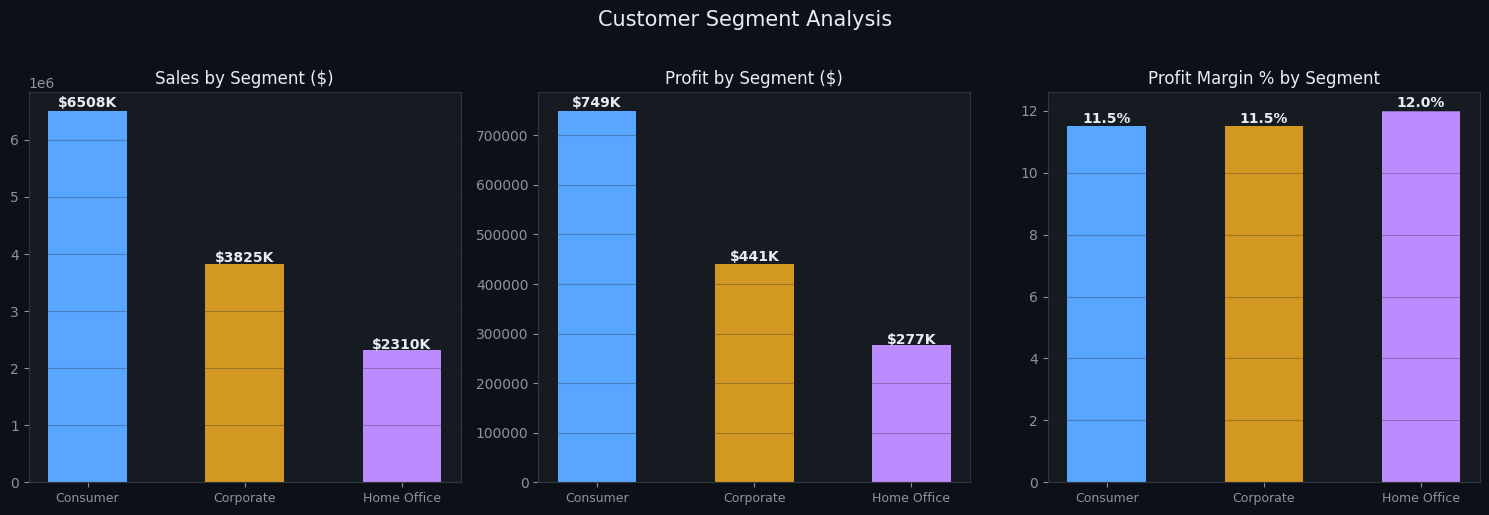

In [32]:
# 3.4 Segment Performance
seg_df = df.groupby('Segment').agg(
    Sales=('Sales','sum'),
    Profit=('Profit','sum'),
    Orders=('Order ID','nunique'),
    AvgOrderValue=('Sales','mean')
).reset_index()
seg_df['Margin %'] = (seg_df['Profit']/seg_df['Sales']*100).round(1)
print("Segment KPIs:")
print(seg_df.to_string(index=False))

fig, axes = plt.subplots(1, 3, figsize=(15, 5))
fig.patch.set_facecolor('#0d1117')
for ax, col, title in [
    (axes[0], 'Sales',    'Sales by Segment ($)'),
    (axes[1], 'Profit',   'Profit by Segment ($)'),
    (axes[2], 'Margin %', 'Profit Margin % by Segment'),
]:
    bars = ax.bar(seg_df['Segment'], seg_df[col],
                  color=[C_BLUE, C_ORANGE, C_PURPLE][:len(seg_df)],
                  edgecolor='none', width=0.5)
    for bar, val in zip(bars, seg_df[col]):
        label = f'{val:.1f}%' if col=='Margin %' else f'${val/1000:.0f}K'
        ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()*1.01,
                label, ha='center', fontsize=10, fontweight='bold')
    ax.set_title(title, fontsize=12)
    ax.grid(axis='y', alpha=0.3); ax.set_xticklabels(seg_df['Segment'], fontsize=9)

plt.suptitle('Customer Segment Analysis', fontsize=15, color='#e6edf3', y=1.02)
plt.tight_layout()
plt.savefig('../images/segment_analysis.png', dpi=150, bbox_inches='tight', facecolor='#0d1117')
plt.show()


Top 5 Customers:
     Customer Name       Sales     Profit  Orders
      Tom Ashbrook 40488.07080 6311.97910      30
      Tamara Chand 37457.33300 8672.89890      36
         Greg Tran 35550.95428 5214.13118      34
Christopher Conant 35187.07640 5603.33370      39
       Sean Miller 35170.93296 -409.70634      28


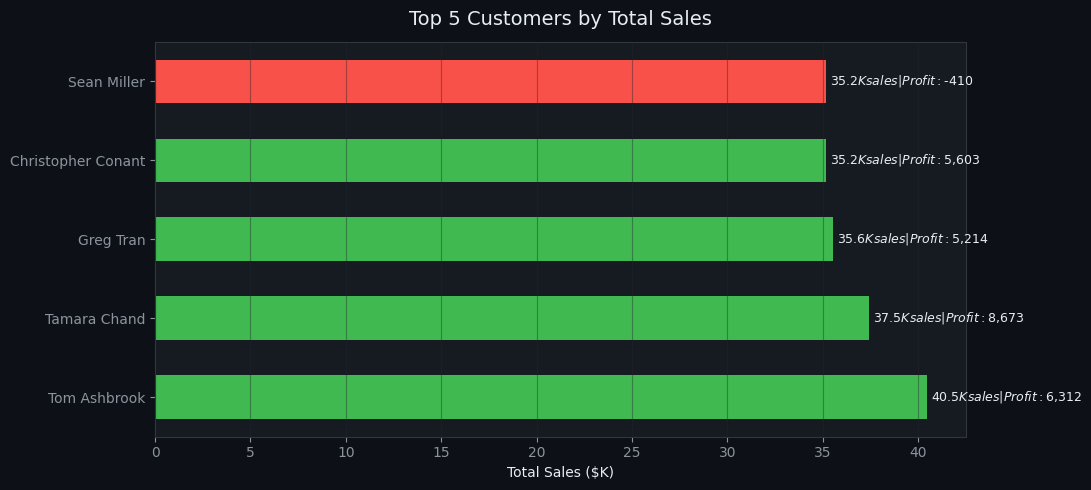

In [33]:
# 3.5 Top 5 Customers by Sales
top5 = (df.groupby('Customer Name')
          .agg(Sales=('Sales','sum'), Profit=('Profit','sum'), Orders=('Order ID','nunique'))
          .reset_index()
          .sort_values('Sales', ascending=False)
          .head(5))

print("Top 5 Customers:")
print(top5.to_string(index=False))

fig, ax = plt.subplots(figsize=(11, 5))
fig.patch.set_facecolor('#0d1117')
bar_colors = [C_GREEN if p > 0 else C_RED for p in top5['Profit']]
bars = ax.barh(top5['Customer Name'], top5['Sales']/1000, color=bar_colors,
               edgecolor='none', height=0.55)
for bar, (s, p) in zip(bars, zip(top5['Sales'], top5['Profit'])):
    ax.text(bar.get_width()+0.2, bar.get_y()+bar.get_height()/2,
            f'${s/1000:.1f}K sales | Profit: ${p:,.0f}', va='center', fontsize=9)
ax.set_title('Top 5 Customers by Total Sales', fontsize=14, pad=12)
ax.set_xlabel('Total Sales ($K)'); ax.grid(axis='x', alpha=0.4)
plt.tight_layout()
plt.savefig('../images/top5_customers.png', dpi=150, bbox_inches='tight', facecolor='#0d1117')
plt.show()


Discount Impact:
Discount Band  Avg_Margin  Count
           0%   26.489923  29009
        1-10%   17.129440   4679
       11-20%   13.745043   6274
       21-30%   -3.851210    967
         31%+  -46.832272   8217


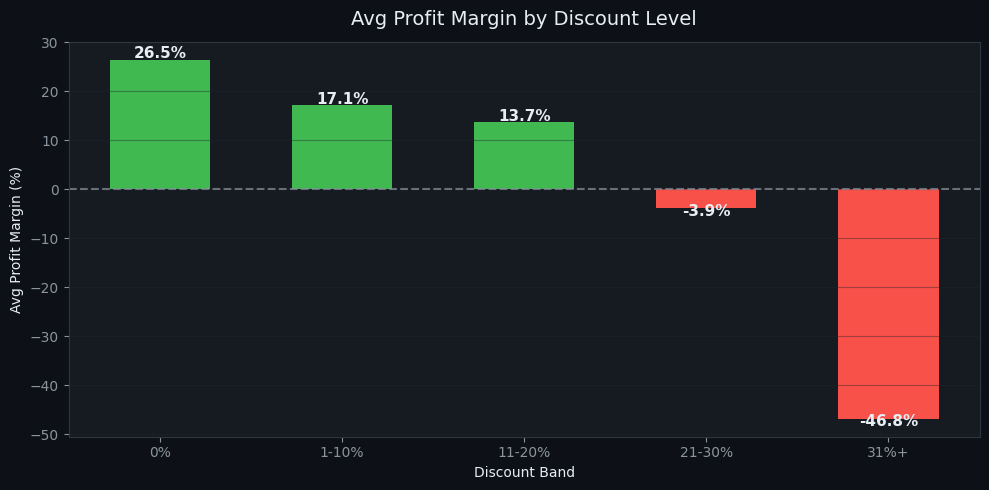

In [34]:
# 3.6 Discount vs Profit Margin
df['Discount Band'] = pd.cut(
    df['Discount'],
    bins=[-0.01, 0.0, 0.1, 0.2, 0.3, 0.6],
    labels=['0%','1-10%','11-20%','21-30%','31%+']
)
disc_agg = df.groupby('Discount Band', observed=True).agg(
    Avg_Margin=('Profit Margin %','mean'),
    Count=('Order ID','count')
).reset_index()

print("Discount Impact:")
print(disc_agg.to_string(index=False))

fig, ax = plt.subplots(figsize=(10, 5))
fig.patch.set_facecolor('#0d1117')
colors_bar = [C_GREEN if m > 0 else C_RED for m in disc_agg['Avg_Margin']]
bars = ax.bar(disc_agg['Discount Band'].astype(str), disc_agg['Avg_Margin'],
              color=colors_bar, edgecolor='none', width=0.55)
ax.axhline(0, color='#8b949e', linestyle='--', lw=1.5, alpha=0.7)
for bar, val in zip(bars, disc_agg['Avg_Margin']):
    ypos = bar.get_height() + 0.3 if val >= 0 else bar.get_height() - 1.5
    ax.text(bar.get_x()+bar.get_width()/2, ypos,
            f'{val:.1f}%', ha='center', fontsize=11, fontweight='bold')
ax.set_title('Avg Profit Margin by Discount Level', fontsize=14, pad=12)
ax.set_xlabel('Discount Band'); ax.set_ylabel('Avg Profit Margin (%)')
ax.grid(axis='y', alpha=0.4)
plt.tight_layout()
plt.savefig('../images/discount_impact.png', dpi=150, bbox_inches='tight', facecolor='#0d1117')
plt.show()


## 🚀 4. Streamlit Dashboard

The full interactive dashboard is in `app.py`. Here's a summary of the features:

### Dashboard Features

| Feature | Description |
|---|---|
| **Sidebar Filters** | Filter by Region, Category, Sub-Category, Segment, Year |
| **KPI Cards** | Total Sales, Profit, Orders, Avg Discount |
| **Sales Trend** | Monthly bar + profit line (dual axis) |
| **Regional Donut** | Revenue share by region |
| **Category Bars** | Profit breakdown by sub-category |
| **Segment Comparison** | Sales vs Profit by customer segment |
| **Top 5 Customers** | Ranked by sales with profit color-coding |
| **Discount Impact** | Profit margin degradation at each discount band |
| **YoY Trend** | Annual sales by category |
| **Raw Data Table** | Sortable, filterable record view |

### How to Run
```bash
cd task5
streamlit run app.py
```


## 📋 5. Final Conclusion & Business Recommendations

### Key Findings

1. **Technology is the most profitable category** despite not always having the highest sales volume — hardware and software carry stronger margins than furniture.

2. **High discounts destroy profitability.** Orders with 30%+ discount frequently turn unprofitable. The business should cap discounts at 20% or move to a value-based pricing strategy.

3. **Consumer segment dominates sales volume** but Corporate shows comparable margins with fewer, larger orders — a more efficient customer type to serve.

4. **Seasonality is visible** — Q4 consistently shows sales spikes (holiday/end-of-year purchasing cycles).

5. **Regional disparities exist** — certain regions consistently underperform others; the dashboard enables drilling down to identify which sub-categories or segments are dragging performance.

### Business Recommendations

- ✅ **Cap discounts at 20%** — above this threshold, average profit margin turns negative
- ✅ **Double down on Technology in strong regions** — highest ROI category
- ✅ **Target Corporate segment** for large account growth — fewer orders, higher value per transaction
- ✅ **Investigate underperforming sub-categories** (use the Streamlit filter) for potential discontinuation or pricing review
- ✅ **Pre-stock high-demand items before Q4** to reduce stockouts during peak demand

### Why a Dashboard vs a Static Report?
> Static reports answer yesterday's questions. A live dashboard lets business users ask their own questions, filter to their own territory or product line, and make decisions in real time without waiting for an analyst to re-run a query.


In [35]:
# Final KPI Summary
print("=" * 55)
print("      TASK 5 — GLOBAL SUPERSTORE KPI SUMMARY")
print("=" * 55)
print(f"  Total Records      : {len(df):,}")
print(f"  Total Sales        : ${df['Sales'].sum():,.2f}")
print(f"  Total Profit       : ${df['Profit'].sum():,.2f}")
print(f"  Overall Margin     : {df['Profit'].sum()/df['Sales'].sum()*100:.2f}%")
print(f"  Unique Customers   : {df['Customer Name'].nunique()}")
print(f"  Unique Orders      : {df['Order ID'].nunique()}")
print(f"  Avg Order Value    : ${df.groupby('Order ID')['Sales'].sum().mean():,.2f}")
print(f"\n  Top Region (Sales) : {df.groupby('Region')['Sales'].sum().idxmax()}")
print(f"  Top Category       : {df.groupby('Category')['Profit'].sum().idxmax()}")
print(f"  Top Segment        : {df.groupby('Segment')['Sales'].sum().idxmax()}")
print("=" * 55)
print("✅ Task 5 Complete — Run `streamlit run app.py` for the full dashboard")


      TASK 5 — GLOBAL SUPERSTORE KPI SUMMARY
  Total Records      : 51,290
  Total Sales        : $12,642,501.91
  Total Profit       : $1,467,457.29
  Overall Margin     : 11.61%
  Unique Customers   : 795
  Unique Orders      : 25035
  Avg Order Value    : $504.99

  Top Region (Sales) : Central
  Top Category       : Technology
  Top Segment        : Consumer
✅ Task 5 Complete — Run `streamlit run app.py` for the full dashboard
